# Basic Fault Network Modeling with Fermi

Fermi is a tool to create fault sources for PSHA that are capable of 
subfault to multifault ruptures, treating the faults as a network.

This is an entry-level tutorial, showing the common useful methods and constraints to build a fault source model. However additional configuration is possible for special cases, to be covered in later tutorials.

## Overview of the Fault Network Modeling process

The modeling process looks like this:

1. Creation of subfaults

    In this step, the fault traces are expanded down-dip to 3D surfaces, and then broken into smaller, atomic units called 'subfaults' that are capable of independent ruptures. The individual subfault ruptures are the smallest on-fault ruptures in the fault source. For regional PSHA models, 10x10 km subfaults are a fine subfault size, which is about a M 6.0 rupture. This can be smaller or larger if desired, for example smaller for site-specific studies, or larger for continental-scale models; the tradeoffs here are the number of ruptures produced and the computational expense in the rupture creation and rate inversion.

1. Creation of single-fault ruptures

   Single-fault ruptures are composed of one or more subfaults. Ruptures with more than one subfault are rectangular groups of contiguous subfaults. These fall within rupture aspect ratio bounds, which are different for ruptures that don't fully saturate the down-dip width of the fault and those that do: ruptures that do are allowed to grow much longer than those that do not, consistent with observations from nature. Note that these aspect ratio bounds are configurable.

1. Creation of multifault ruptures

    Multifault ruptures are created by joining single-fault ruptures that are separated by a 'jump' distance less than some specified value (typically 5-10 km). This is done through graph theoretical methods: a N x N distance matrix is created (where N is the number of ruptures) and then this matrix is pared for distances greater than the jump distance, creating an adjacency matrix. Then, all of the unique sets of adjacent ruptures is found through a depth-first search algorithm operating on the adjacency matrix.

    This typically produces an enormous number of ruptures, so additional filtering should be done on the adjacency matrix before the multifault ruptures are created. The most substantial is limiting multifault ruptures to be combinations of full-fault single-fault ruptures (rather than all subfault ruptures), which for reasons of computational expense will need to be done when more than a few faults are involved, unless one wants to use an HPC system or the subfaults themselves are >20x20 km. This is in line with theory and observations suggesting that earthquake ruptures are much more likely to stop at geometric complexities in faults (including gaps and stepovers) than in the middle of fault segments. Similarly, the geometrical compatibilities between faults themselves can be quantified and used as a filter on the adjacency matrix.

1. (Optional) Plausibility filtering of multifault ruptures

    Research of rupture propagation through geometrical complexities and related topics indicates that not all potential multifault ruptures are equally plausible. Therefore, we can increase the model's fidelity to nature and reduce its computational load by filtering the ruptures by their plausbility. The plausibility of a rupture is quantified by assessing the jump distance, the angular distance between the traces of adjacent faults, and the angular distance between the azimuth of slip between adjacent faults; each of these yields a plausibility value between 0 and 1 for each connection between faults (or ruptures), which are multiplied for each connection: a three-fault rupture will have a total plausibility value that is the product of the three criteria for two connections. The ruptures are then stochastically filtered by their plausibility, by sampling a uniform random number from [0-1) for each rupture and comparing to the plausibility; if the plausbility is higher than the random number, the rupture is retained. All single-fault ruptures have a plausibility of 1.0 so they are not filtered. Tuning parameters exist for the plausibility calculations for each criterion.

    In this tutorial, the plausibility filtering is not used.

1. Rupture rate inversion

    Once Fermi has made the ruptures, the next step is to determine the annual occurrence rates of each rupture, through an inversion of geological and seismological constraints, such as fault slip rates and magnitude-frequency distributions. This happens through the creation of a system of linear equations which represent the constraints, which is solved using a non-negative least-squares solver developed for this application.

    1. *Choosing constraints* There are a variety of data types and constraints that can be used to solve for the rupture rates. The most commonly used by nearly all workers in the field are fault slip rates, which may be found through geologic or geodetic means. We are also using two types of magnitude-frequency distribution information. The first is a normal magnitude-frequency distribution, which has absolute rates (frequencies) for each magnitude bin. The second is what is here called a 'relative' magnitude-frequency distribution, in which only the shape (the relative rates) of the MFD is used, i.e. there is a b-value but no a-value. We will use the absolute MFD as a constraint on the model-wide magnitude-frequency distribution, and relative MFDs for each fault, to ensure that the faults are producing a range of magnitudes.
      
    1. *Solving for the rupture rates* Once the constraints have been chosen, a system of equations is created; each constraint becomes a block of equations, that are then stacked to form the final system. Though the system is linear (i.e., the variables we are solving for, the rupture rates, are related to each other additively not multiplicatively), we can't do a direct solve on the system because the solution must be non-negative--rupture rates can be zero, but not negative (that would be meaningless). We use a non-negative projected-gradient weighted least-squares solver, which is an iterative method that offers rapid convergence.
  

1. Writing fault sources

   After the rupture rates have been determined, the fault network can be saved as an OpenQuake fault source.

## Building the fault network

First we must import the modules and functions.

In [1]:
# Start the logging with level INFO to provide
# good information about the progress and results

import logging
logging.basicConfig(
    format='%(asctime)s - %(message)s',
    datefmt='%d-%b-%y %H:%M:%S',
    level=logging.INFO,
)

Fermi is the `openquake.fnm` module. The basic entry point is the `openquake.fnm.all_together_now` submodule,
which provides the functions `build_fault_network` and `build_system_of_equations`. 

However, we are also going to import a number of other functions to allow us
to use more constraints in solving for the rupture rates, such as magnitude-frequency constraints for all of the faults involved as well as for the region.

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from openquake.hazardlib.mfd import TruncatedGRMFD

from openquake.fnm.exporter import (
    make_multifault_source,
    write_multifault_source,
)
from openquake.fnm.all_together_now import (
    build_fault_network,
    build_system_of_equations,
)
from openquake.fnm.inversion.utils import (
    rup_df_to_rupture_dicts,
    get_fault_moment_rate,
    make_fault_mfd,
)
from openquake.fnm.inversion.plots import (
    plot_soln_slip_rates,
    plot_soln_mfd,
    plot_mfd,
)
from openquake.fnm.inversion.soe_builder import (
    make_fault_rel_mfd_equation_components,
)

from openquake.fnm.inversion.solver import solve_nnls_pg

### Settings for the fault network creation

Fault network modeling is complex; there are a number of parameters that control many of the aspects of the process, such as the size of the subfaults, the maximum jump distance, whether to filter by plausibility, etc. Note that these settings do not directly control the rupture rate inversion--that comes later.

The list of the available settings and their defaults may be found [in the documentation](https://github.com/GEMScienceTools/oq-mbtk/blob/7cbd649c7c46f17afc44a4664686d621e9fec53e/openquake/fnm/all_together_now.py#L59).

In [3]:
settings = {
    # fraction of slip rate released in mainshocks
    "seismic_fraction": 1.0, 
    # Size of subfault length/width in km
    "subsection_size": 10.0, 
    "max_jump_distance": 10.0, # maximum 3d distance between faults that can co-rupture
    "parallel_subfault_build": True, #set to False if you run in IPython interactively
    'full_fault_only_mf_ruptures': True, # Set to False for site-specific analysis with just a few faults
    "filter_by_plausibility": True, #set to True if you want to remove some geometrically implausible ruptures
    "fault_mfd_b_value": 1.0, # change as you like
    "export_fault_mfds": True, # create MFD objects for faults during processing
}

### Loading the fault data

This file shows a part of the Altyn Tagh and Qilian Shan in northern Tibet. The total fault system covers several hundred kilometers in either direction and shows much of the complexity inherent in fault systems worldwide, while still being small enough to be handled in a short amount of time by Fermi.

In [4]:
fault_geojson = "../../../../openquake/fnm/tests/data/atf_qilian.geojson"

Warning 3: Cannot find header.dxf (GDAL_DATA is not defined)
/Users/itchy/src/miniforge3/envs/oq2/lib/python3.12/site-packages/pyogrio/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


<Axes: >

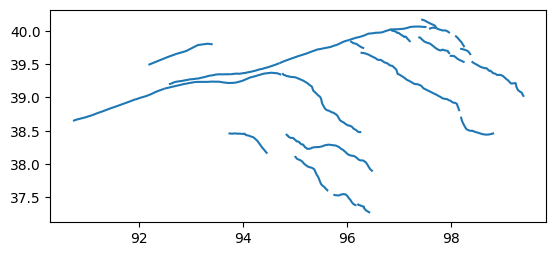

In [5]:
gpd.read_file(fault_geojson).plot()

Now let's look at the attributes of the data. The required ones are:



In [6]:
gpd.read_file(fault_geojson).head()

,extension_err,cde,name,net_slip_rate,extension_rate,lsd,net_slip_rate_err,hw,dip_dir,fid,dextral_err,fw,dip,dextral_rate,usd,rake,geometry
0,0.093,0.001,,3.725,0.091,20.0,0.078,104,S,282,0.078,103,89.0,-3.724,0.0,0.0,"LINESTRING (90.73336 38.64673, 90.73935 38.648..."
1,0.086,0.004,,2.546,-2.511,15.0,0.094,122,SW,309,0.114,115,15.0,-0.421,0.0,5.9,"LINESTRING (98.39916 39.53902, 98.43676 39.516..."
2,0.075,-0.001,Luliang Thrust,2.873,-1.860,15.0,0.075,140,NE,331,0.066,104,15.0,2.191,0.0,179.2,"LINESTRING (95.64242 37.59772, 95.63424 37.600..."
3,0.140,-0.004,Qaidam Thrust,1.551,-0.321,15.0,0.111,141,NE,332,0.118,140,15.0,-1.518,0.0,0.2,"LINESTRING (96.49668 37.88915, 96.44849 37.922..."
4,0.237,-0.024,,1.591,-1.460,15.0,0.186,138,NE,333,0.180,141,15.0,-0.634,0.0,2.3,"LINESTRING (96.27662 38.47767, 96.26163 38.479..."


### Building the fault network

This is done with a single command. The fault network is a dictionary of the different components.

In [7]:
fault_network = build_fault_network(
        fault_geojson=fault_geojson,
        settings=settings,
        )

21-Mar-26 07:01:50 - Building faults from geojson
21-Mar-26 07:01:50 - 	27 faults built from geojson
21-Mar-26 07:01:50 - 	done in 0.1 s
21-Mar-26 07:01:50 - Making subfaults in parallel
21-Mar-26 07:01:56 - 	done in 6.8 s
21-Mar-26 07:01:56 - 	828 subfaults from 27 faults
21-Mar-26 07:01:56 - Making single fault rup df and distance matrix
21-Mar-26 07:01:56 -   making single-fault ruptures
21-Mar-26 07:01:56 -   calculating fault distances
21-Mar-26 07:01:56 -   making dist_adj_matrix (7046, 7046)
21-Mar-26 07:01:56 -   filtering and calculating pairwise rupture distances
21-Mar-26 07:01:57 - 	done in 0.5 s
21-Mar-26 07:01:57 - 	7,046 single-fault ruptures
21-Mar-26 07:01:57 - 	64 close ruptures out of 4,096 connections (1.6%)
21-Mar-26 07:01:57 -   Filtering by rupture overlap
21-Mar-26 07:01:57 -    Getting proximal rup angles
21-Mar-26 07:01:57 -    Calculating overlap
21-Mar-26 07:01:57 - 	done in 0.3 s
21-Mar-26 07:01:57 - 	50 connections remaining
21-Mar-26 07:01:57 - Building s

### Making constraints for the rupture rate inversion

The first step is to choose the set of ruptures that we'll use in the model. 
Because we are not filtering by plausibility, this choice is made for us.
The ruptures are found in a Pandas dataframe, `fault_network['rupture_df']`.
If we were choosing to filter the ruptures, and then use the filtered set,
we would find that at `fault_network['rupture_df_keep']`. We will also make a
dictionary out of the ruptures that we want to use, which makes certain steps
easier.

In [8]:
rup_key = 'rupture_df'
rup_set = fault_network[rup_key]
rups = rup_df_to_rupture_dicts(rup_set)

Now we're going to create relative MFD constraints for each fault.

In [9]:
# MFD constraints (b-value only, no a-value) for faults
fault_rel_mfds = make_fault_rel_mfd_equation_components(
    rups,
    fault_network,
    b_value=settings['fault_mfd_b_value'],
    fault_key='faults',
    rup_key=rup_key,
    )

Here we create an absolute MFD for the whole fault. Fermi can use any OpenQuake MFD class
in the inversion, or a dictionary with magnitude bins and rates. In most cases, one would
fit an MFD to the regional seismicity, which requires estimating the completeness as well.
We won't get into that here, so instead we will fit one to the total moment rate of the faults.

In [10]:
# absolute MFD for whole model
fault_moment = sum(get_fault_moment_rate(fault) 
                   for i, fault in fault_network['subfault_df'].iterrows())
model_abs_mfd = TruncatedGRMFD.from_moment(
    min_mag=rup_set.mag.min(),
    max_mag=rup_set.mag.max(),
    bin_width=0.1,
    b_val=1.0, # as you'd like
    moment_rate=fault_moment,
)

Now we build the system of equations. We use the ruptures we've selected, and we are making
slip rate equations for each subfault, not each fault. We are using the per-fault relative
MFDs and the model-wide absolute MFD. You can see here how you'd make a model-wide relative MFD
if you wanted to, and how to change its b-value.

The system of equations is represented by the `lhs`, the left-hand-side matrix of equations
(often called the design matrix); the `rhs`, the right-hand side vector of 'knowns' that we want
to target (i.e. the actual slip rates or MFD bin rates); and the `err` vector of weights, which are
derived from the uncertainties for the slip rates, and more arbitrary weights for the bin rates
and other constraints.

In [11]:
lhs, rhs, err = build_system_of_equations(
    rup_set,
    fault_network["subfault_df"],
    fault_rel_mfds=fault_rel_mfds,
    mfd_rel_weight=1e2,
    mfd_rel_mode='shape',
    #mfd_rel_eqns=True, # if you want a regional (relative, no a-value) MFD
    #mfd_rel_b_val=1.0, # adjust as you'd like,
    mfd=model_abs_mfd, # set to None if you don't want to use
)

21-Mar-26 07:01:59 - Making slip rate eqns
21-Mar-26 07:02:00 - Making regional MFD relative eqns
21-Mar-26 07:02:00 - Making MFD absolute eqns
21-Mar-26 07:02:00 - stacking results


Now we'll solve the equations. There are several stopping conditions. The solver is relatively rapid;
for this model with 7000 ruptures, we can get a good solution in a few minutes. Note that the speed of
convergence is determined not only by the number of ruptures in the system, but by the nature of the constraints
and how steep the gradient is. Sometimes adding constraints can cause a solution to be reached in seconds,
and sometimes it can take much longer.

My recommendation is to start with a small number of iterations (~1e4), see how fast it takes and the
quality of the solution, and then work up from there. The best stopping condition is the `stall_val` which
triggers when the misfit history stops improving, but this needs to be calibrated for each problem.

Here we're using 200,000 iterations, which takes a few minutes on a modern laptop.

In [12]:
logging.info("Solving")
rup_rates, misfit_history = solve_nnls_pg(
    lhs,
    rhs,
    weights=err,
    max_iters=int(2e5),
    accept_grad=-1, # continue to completion of iterations
    accept_norm=-1, # continue to completion of iterations
    stall_val=1e-6, # continue until solutions is pretty stable
)
rup_rates = pd.Series(rup_rates, index=rup_set.index)
logging.info("Done solving")

21-Mar-26 07:02:00 - Solving
21-Mar-26 07:05:37 - Done solving


Now we're done and we can set the rates.

In [13]:
rup_set["occurrence_rate"] = rup_rates

Let's look at the results:

Text(0.5, 1.0, 'Observed and modeled slip rates')

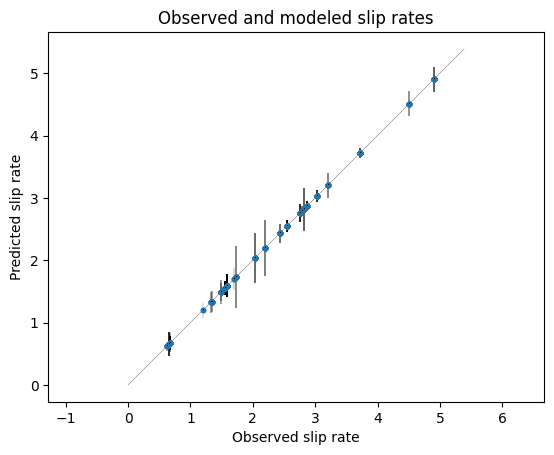

In [14]:
plt.figure()
plot_soln_slip_rates(
    rup_rates,
    fault_network['subfault_df'].net_slip_rate,
    lhs,
    errs=fault_network["subfault_df"].net_slip_rate_err,
    units="mm/yr",
)
plt.title("Observed and modeled slip rates")

Text(0.5, 1.0, 'Solution MFD')

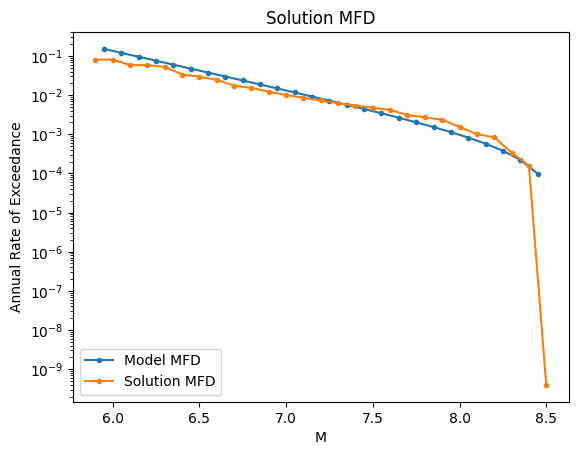

In [15]:
plt.figure()
plot_mfd(model_abs_mfd, label="Model MFD")
plot_soln_mfd(rup_rates.values, rups, label="Solution MFD")
plt.legend(loc="lower left")
plt.title("Solution MFD")

Text(0.5, 1.0, 'Solution misfit history')

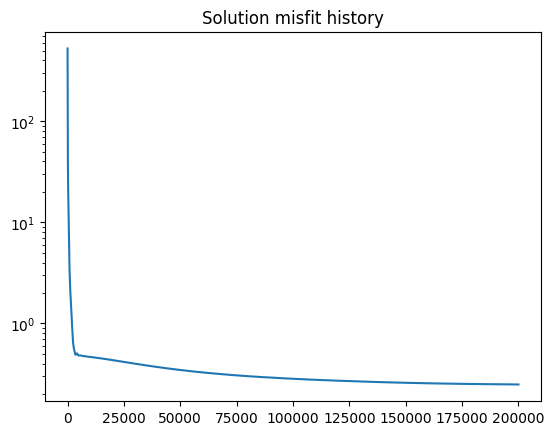

In [16]:
plt.figure()
plt.semilogy(misfit_history)
plt.title("Solution misfit history")

### Writing the results to an OpenQuake source

In [17]:
mfs = make_multifault_source(
    fault_network,
    source_id='atf_qilian',
    name="Altyn Tagh--Qilian Shan faults",
    ruptures_for_output='all', #use 'filtered' if you filtered by plausibility
    rupture_occurrence_rates=rup_rates,
)

write_multifault_source(".", mfs)